# Notebook 01: データ探索

**目的**: 米国債の利回りデータを FRED から取得し、構造を把握する。

## やること
1. FRED から米国債の利回り(10年限)を 2020 年〜現在 で取得
2. 欠損値の確認と処理
3. 各年限の時系列プロット
4. `data/raw/` と `data/processed/` に保存

## チェックポイント
- [ ] データの shape は `(N営業日, 10年限)` になっているか
- [ ] 欠損日数を把握したか(連休・米国祝日)
- [ ] 各年限の時系列が金利として妥当な範囲(0〜6%程度)か

## 観察してほしいこと
- 2022年からのFRB急激な利上げで全カーブが上方シフト
- 2y と 10y の差が一時的にマイナス(逆イールド)になった時期がある

## 0. セットアップ

ライブラリを import し、定数を定義する。

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# プロジェクトルートを明示する(Notebookから見るとnotebooks/の親)
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# 取得する年限と FRED の系列ID
# 一般的なPCA分析で使われる10年限(1Mは値動きが激しすぎ、20Yは2020年再開なので除外)
MATURITIES = {
    "DGS3MO": "3M",
    "DGS6MO": "6M",
    "DGS1": "1Y",
    "DGS2": "2Y",
    "DGS3": "3Y",
    "DGS5": "5Y",
    "DGS7": "7Y",
    "DGS10": "10Y",
    "DGS20": "20Y",
    "DGS30": "30Y",
}

START_DATE = "2020-01-01"
END_DATE = "2026-04-30"

# プロット設定
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")
print(f"Maturities to fetch: {list(MATURITIES.values())}")

Project root: C:\FICC
Maturities to fetch: ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']


## 1. FRED からデータを取得

**方針**: `pandas-datareader` は最新 pandas と互換性問題があるため、FRED の公開 CSV エンドポイントから直接取得する。

URL: `https://fred.stlouisfed.org/graph/fredgraph.csv?id=<SERIES_ID>&cosd=<START>&coed=<END>`

複数系列を一発で取りたいところだが、FRED API は date range が最初の系列にしか効かない仕様(検証済)。
なので **1系列ずつ取得して merge** する。

In [2]:
def fetch_fred_series(series_id: str, start: str, end: str) -> pd.Series:
    """FRED から1つの時系列を取得する。値がない日は NaN で返ってくる。"""
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id={series_id}&cosd={start}&coed={end}"
    )
    df = pd.read_csv(url, parse_dates=["observation_date"])
    return df.set_index("observation_date")[series_id]


# 全系列を取得
series_dict = {}
for fred_id, label in MATURITIES.items():
    print(f"Fetching {fred_id} ({label})...")
    series_dict[label] = fetch_fred_series(fred_id, START_DATE, END_DATE)

# 横に結合(各列が年限、行が日付)
yields = pd.concat(series_dict, axis=1)
yields.columns.name = "maturity"
yields.index.name = "date"

print(f"\nShape: {yields.shape}  (期待: (N営業日, 10))")
yields.head()

Fetching DGS3MO (3M)...


Fetching DGS6MO (6M)...


Fetching DGS1 (1Y)...


Fetching DGS2 (2Y)...


Fetching DGS3 (3Y)...


Fetching DGS5 (5Y)...
Fetching DGS7 (7Y)...


Fetching DGS10 (10Y)...
Fetching DGS20 (20Y)...


Fetching DGS30 (30Y)...



Shape: (1648, 10)  (期待: (N営業日, 10))


maturity,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,
2020-01-02,1.54,1.57,1.56,1.58,1.59,1.67,1.79,1.88,2.19,2.33
2020-01-03,1.52,1.55,1.55,1.53,1.54,1.59,1.71,1.80,2.11,2.26
2020-01-06,1.56,1.56,1.54,1.54,1.56,1.61,1.72,1.81,2.13,2.28
2020-01-07,1.54,1.56,1.53,1.54,1.55,1.62,1.74,1.83,2.16,2.31
2020-01-08,1.54,1.56,1.55,1.58,1.61,1.67,1.78,1.87,2.21,2.35


## 2. データの構造確認

### 2.1 基本統計

In [3]:
yields.describe().round(2)

maturity,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
count,1580.00,1580.00,1580.00,1580.00,1580.00,1580.00,1580.00,1580.00,1580.00,1580.00
mean,2.90,2.92,2.86,2.78,2.75,2.80,2.92,3.02,3.43,3.41
std,2.22,2.15,2.02,1.83,1.70,1.55,1.46,1.40,1.35,1.26
min,0.00,0.02,0.04,0.09,0.10,0.19,0.36,0.52,0.87,0.99
25%,0.12,0.15,0.18,0.38,0.57,0.94,1.33,1.57,2.05,2.09
50%,3.73,3.78,3.66,3.59,3.58,3.63,3.72,3.69,4.00,3.83
75%,4.79,4.82,4.66,4.28,4.14,4.04,4.12,4.23,4.63,4.59
max,5.63,5.61,5.49,5.19,5.03,4.95,5.00,4.98,5.30,5.11


**チェック**: 各年限の min/max が 0〜6% の範囲に収まっているか。
- 2020年のコロナショックで短期金利は 0% 近くまで下がった
- 2023〜2024年の利上げ局面で 5%超まで上昇した年限もある

### 2.2 欠損値の確認

In [4]:
missing = yields.isna().sum()
missing_pct = (missing / len(yields) * 100).round(1)
missing_summary = pd.DataFrame({
    "missing_days": missing,
    "missing_pct": missing_pct,
})
print(f"全行数: {len(yields)}")
missing_summary

全行数: 1648


,missing_days,missing_pct
maturity,,
3M,68,4.1
6M,68,4.1
1Y,68,4.1
2Y,68,4.1
3Y,68,4.1
5Y,68,4.1
7Y,68,4.1
10Y,68,4.1
20Y,68,4.1


**観察**:
- 全年限に共通する NaN 日は **米国祝日**(MLKデー、独立記念日、サンクスギビング等)
- 20Y は 2020年5月再開なので、それ以前のデータが NaN(本データは 2020-01 開始なので影響は小さい)

### 2.3 全列が NaN の日(=祝日と推定)を除外

In [5]:
all_nan_days = yields.isna().all(axis=1).sum()
print(f"全列が NaN の日: {all_nan_days} 日")

yields_clean = yields.dropna(how="all")
print(f"祝日除外後の shape: {yields_clean.shape}")

全列が NaN の日: 68 日
祝日除外後の shape: (1580, 10)


### 2.4 部分欠損の処理

全列ではないが一部欠損(例: 20Y だけ NaN)が残る日もありうる。
PCA は全列の値が必要なので、**1つでも欠損がある日は除外** する。

(将来的には補間も検討可能だが、今回は素直に dropna)

In [6]:
yields_full = yields_clean.dropna(how="any")
dropped = len(yields_clean) - len(yields_full)
print(f"部分欠損で除外された日: {dropped} 日")
print(f"最終的なクリーンデータ shape: {yields_full.shape}")

部分欠損で除外された日: 0 日
最終的なクリーンデータ shape: (1580, 10)


## 3. 可視化

### 3.1 全年限の時系列プロット

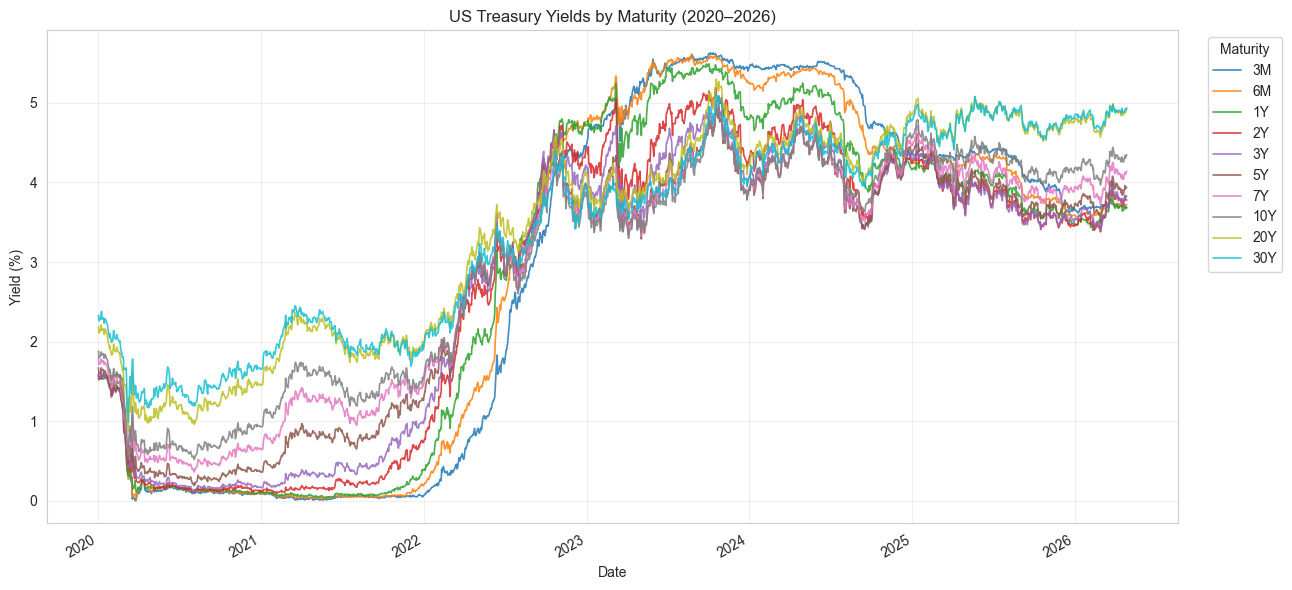

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
yields_full.plot(ax=ax, lw=1.2, alpha=0.85)
ax.set_title("US Treasury Yields by Maturity (2020–2026)")
ax.set_ylabel("Yield (%)")
ax.set_xlabel("Date")
ax.legend(title="Maturity", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**観察ポイント**:
- 2020年: コロナで全カーブが0%付近まで沈む(FRBがゼロ金利)
- 2022年〜2023年: 急激な利上げで全カーブが上方シフト(短期 → 長期の順に上昇)
- 2023〜2024年: 短期(2Y, 3M)が長期(10Y, 30Y)を上回っている期間 = **逆イールド**
- 2024年後半〜: 利下げ転換で短期が下がり始め、カーブが正常化

### 3.2 2y - 10y スプレッド(逆イールドの可視化)

「2s10s スプレッド」と呼ばれる、最も watch されている指標の1つ。
**マイナス = 逆イールド(短期 > 長期)= 景気後退の予兆とされる**

C:\Users\hasel\AppData\Local\Temp\ipykernel_52752\4014123315.py:15: UserWarning: Glyph 36870 (\N{CJK UNIFIED IDEOGRAPH-9006}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_52752\4014123315.py:15: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_52752\4014123315.py:15: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_52752\4014123315.py:15: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_52752\4014123315.py:15: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_52752\4014123315.py:15: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from

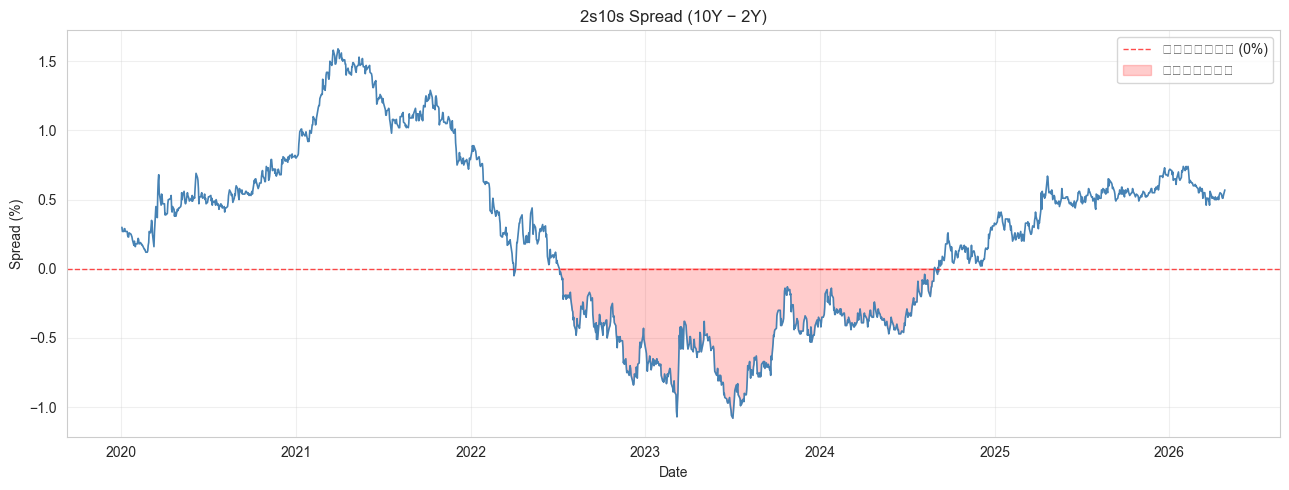

逆イールドだった日数: 541 日 (34.2%)


In [8]:
spread_2s10s = yields_full["10Y"] - yields_full["2Y"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(spread_2s10s.index, spread_2s10s.values, lw=1.2, color="steelblue")
ax.axhline(0, color="red", ls="--", lw=1, alpha=0.7, label="逆イールド境界 (0%)")
ax.fill_between(
    spread_2s10s.index, spread_2s10s.values, 0,
    where=(spread_2s10s < 0), color="red", alpha=0.2, label="逆イールド期間",
)
ax.set_title("2s10s Spread (10Y − 2Y)")
ax.set_ylabel("Spread (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 逆イールド期間の長さ
inverted_days = (spread_2s10s < 0).sum()
print(f"逆イールドだった日数: {inverted_days} 日 ({inverted_days/len(spread_2s10s)*100:.1f}%)")

### 3.3 ある日のカーブ形状(スナップショット)

イールドカーブの「形」を1日分可視化する。横軸=年限、縦軸=利回り。

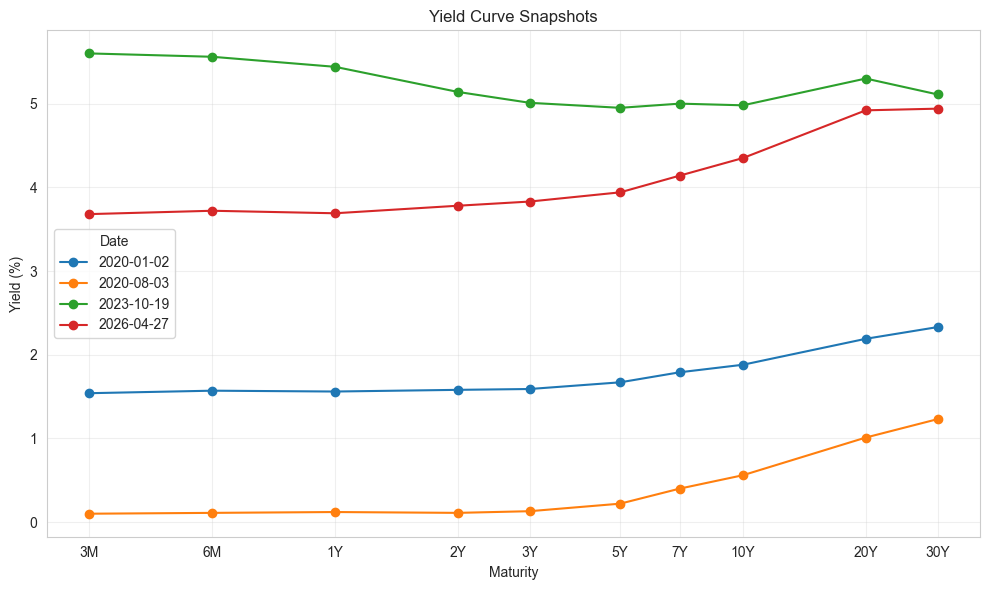

In [9]:
# 年限を年単位の数値に変換(プロット用)
MATURITY_YEARS = {
    "3M": 0.25, "6M": 0.5, "1Y": 1, "2Y": 2, "3Y": 3,
    "5Y": 5, "7Y": 7, "10Y": 10, "20Y": 20, "30Y": 30,
}
x = np.array([MATURITY_YEARS[c] for c in yields_full.columns])

# 4つの代表日を選ぶ
snapshot_dates = [
    yields_full.index.min(),                            # 2020 年初(コロナ前)
    pd.Timestamp("2020-08-03"),                          # コロナ後の超低金利
    pd.Timestamp("2023-10-19"),                          # 利上げ局面ピーク付近
    yields_full.index.max(),                            # 最新
]
snapshot_dates = [d for d in snapshot_dates if d in yields_full.index]

fig, ax = plt.subplots(figsize=(10, 6))
for d in snapshot_dates:
    ax.plot(x, yields_full.loc[d].values, marker="o", lw=1.5, label=d.strftime("%Y-%m-%d"))
ax.set_xscale("log")
ax.set_xticks(x)
ax.set_xticklabels(yields_full.columns)
ax.set_title("Yield Curve Snapshots")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield (%)")
ax.legend(title="Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**観察**:
- 通常は **右肩上がり**(長期金利 > 短期金利)
- 2023年あたりは **逆向き**(短期 > 長期)= 逆イールド
- カーブの「形」がイベントごとに大きく違うことがわかる

## 4. 保存

- `data/raw/`: 取得した生データを CSV で保存(再現性のため)
- `data/processed/`: クリーンアップ済みデータを parquet で保存(以降の Notebook で使う)

In [10]:
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# 生データ(欠損込み)
raw_path = DATA_RAW / "ust_yields_raw.csv"
yields.to_csv(raw_path)
print(f"Saved raw:       {raw_path}")

# クリーンデータ(欠損なし)
clean_path = DATA_PROCESSED / "ust_yields_clean.parquet"
yields_full.to_parquet(clean_path)
print(f"Saved processed: {clean_path}")

# サイズ確認
print(f"\nRaw CSV size:       {raw_path.stat().st_size / 1024:.1f} KB")
print(f"Processed parquet:  {clean_path.stat().st_size / 1024:.1f} KB")

Saved raw:       C:\FICC\data\raw\ust_yields_raw.csv
Saved processed: C:\FICC\data\processed\ust_yields_clean.parquet

Raw CSV size:       95.8 KB
Processed parquet:  51.3 KB


## 5. まとめ

### 達成したこと
- ✅ FRED から 10年限の利回りデータを取得
- ✅ 欠損値を確認・除外
- ✅ 時系列プロットで全体感を把握
- ✅ 2s10s スプレッドで逆イールド期間を可視化
- ✅ カーブのスナップショットで形の変化を観察
- ✅ raw / processed を保存

### この Notebook で得た理解
- **イールドカーブは日々形が変わる**(平行移動だけではない)
- 2022〜2024年の **逆イールド** は歴史的に長く続いた
- データには **米国祝日の NaN** が含まれるので前処理が必要

### 次の Notebook へ
Notebook 02 では、このクリーンデータを使って:
- カーブの**月次スナップショット**を重ね描き
- **日次変化(差分)を bp 単位で可視化**
- ベア・スティープ / ブル・フラットの 4 分類を導入